In [2]:
import os
import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import cupy as cp
import cudf
from cuml.manifold import TSNE
import matplotlib.pyplot as plt

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
    plot_contour
)

optuna.logging.set_verbosity(optuna.logging.INFO)
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)
os.environ["CC"] = "/usr/bin/gcc"
torch.set_float32_matmul_precision('high')



In [10]:
# Définissez ici les colonnes physiques à utiliser
phys_columns = ["TEFF", "LOGG", "J", "H", "K"]

# Chargement des CSV
train_df = pd.read_csv('../../../data/train_resample_standard_all.csv')
test_df = pd.read_csv('../../../data/test_resample_standard_all.csv')

# Création du tenseur unique pour les valeurs physiques
y_phys_train = torch.tensor(train_df[phys_columns].values, dtype=torch.float32)
y_phys_test  = torch.tensor(test_df[phys_columns].values, dtype=torch.float32)

# On conserve les features chimiques en retirant les colonnes d'ID et physiques
columns_to_drop = ["apogee_id"] + phys_columns
X_train_df = train_df.drop(columns=columns_to_drop).astype('float32').reset_index(drop=True)
X_test_df  = test_df.drop(columns=columns_to_drop).astype('float32').reset_index(drop=True)

X_train = torch.tensor(X_train_df.values, dtype=torch.float32)
X_test  = torch.tensor(X_test_df.values, dtype=torch.float32)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

data_id_train = train_df["apogee_id"]
data_id_test = test_df["apogee_id"]

data_id_full = pd.concat([data_id_train, data_id_test], ignore_index=True)
X_full = torch.cat([X_train, X_test], dim=0)


X_train shape: torch.Size([129124, 17])
X_test shape : torch.Size([32282, 17])


In [4]:
class SiamesePairsDataset(Dataset):
    """
    Ce dataset génère des paires d'étoiles (x_i, x_j) avec leurs vecteurs
    physiques associés, sans utiliser de label binaire, la similarité
    sera calculée en continu dans la loss.
    """
    def __init__(self, X, phys):
        """
        X: tenseur [N, D] des features chimiques
        phys: tenseur [N, n_phys] des paramètres physiques
        """
        super().__init__()
        self.X = X
        self.phys = phys
        self.N = X.shape[0]

    def __len__(self):
        # On génère environ 2*N paires par époque
        return self.N * 2

    def __getitem__(self, idx):
        # Sélection aléatoire d'une étoile "ancre"
        i = np.random.randint(0, self.N)
        x_i = self.X[i]
        phys_i = self.phys[i]

        # Sélection aléatoire d'une deuxième étoile
        j = np.random.randint(0, self.N)
        x_j = self.X[j]
        phys_j = self.phys[j]

        # On ne calcule pas ici la similarité continue, on renverra les deux vecteurs
        return x_i, x_j, phys_i, phys_j

In [5]:
# Création des datasets et dataloaders
train_dataset = SiamesePairsDataset(X_train, y_phys_train)
test_dataset  = SiamesePairsDataset(X_test, y_phys_test)

train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=2048, shuffle=False)

In [6]:
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim, embedding_dim=4):
        super(EmbeddingNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, embedding_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x)
        z = self.fc3(x)
        return z

class SiameseMultiTaskNetwork(nn.Module):
    def __init__(self, input_dim, embedding_dim=4, phys_out_dim=5):
        """
        phys_out_dim: dimension de la régression physique (ici 5, mais peut varier)
        """
        super(SiameseMultiTaskNetwork, self).__init__()
        self.embedding_net = EmbeddingNet(input_dim, embedding_dim)
        # Régression physique à partir de l'embedding
        self.regressor = nn.Linear(embedding_dim, phys_out_dim)

    def forward_once(self, x):
        z = self.embedding_net(x)
        out_phys = self.regressor(z)  # prédiction des paramètres physiques
        return z, out_phys

    def forward(self, x1, x2):
        z1, out1 = self.forward_once(x1)
        z2, out2 = self.forward_once(x2)
        return (z1, out1), (z2, out2)


In [7]:
def compute_similarity(phys_i, phys_j, sigma=0.1):
    """
    Calcule une similarité continue à partir de deux vecteurs physiques.
    La similarité est proche de 1 si la distance est faible, et tend vers 0 sinon.
    """
    d = torch.norm(phys_i - phys_j, p=2)
    sim = torch.exp(- (d ** 2) / (2 * sigma ** 2))
    return sim

def continuous_contrastive_loss(z1, z2, similarities, margin=1.0):
    """
    Loss contrastive continue.
      - Pour des paires très similaires (sim ≈ 1), on pénalise le carré de la distance.
      - Pour des paires peu similaires (sim ≈ 0), on pénalise si la distance est inférieure à une marge.
    """
    d = F.pairwise_distance(z1, z2, p=2)
    loss = similarities * (d ** 2) + (1 - similarities) * (F.relu(margin - d) ** 2)
    return loss.mean()

def multitask_loss_continuous(z1, z2, out1, phys1, out2, phys2,
                              alpha=1.0, beta=1.0, gamma=1.0,
                              margin=1.0, sigma=0.1):
    """
    Calcule une loss multitâche qui combine :
      - Un terme contrastif sur les embeddings (chimique) pondéré par alpha.
      - Un terme contrastif sur les prédictions physiques (similarité physique) pondéré par beta.
      - Une loss de régression MSE entre les prédictions physiques et les valeurs réelles, pondérée par gamma.
    Les similarités sont calculées de manière continue à partir des valeurs physiques réelles.
    """
    batch_size = phys1.size(0)
    similarities = torch.zeros(batch_size, device=phys1.device)
    # Calcul de la similarité pour chaque paire du batch
    for i in range(batch_size):
        similarities[i] = compute_similarity(phys1[i], phys2[i], sigma=sigma)
    
    # Terme contrastif sur l'embedding (chimique)
    loss_chem = continuous_contrastive_loss(z1, z2, similarities, margin=margin)
    # Terme contrastif sur les prédictions physiques
    loss_phys_cont = continuous_contrastive_loss(out1, out2, similarities, margin=margin)
    # Terme de régression (MSE) pour la branche physique
    mse1 = F.mse_loss(out1, phys1)
    mse2 = F.mse_loss(out2, phys2)
    loss_phys_reg = (mse1 + mse2) / 2.0

    total_loss = alpha * loss_chem + beta * loss_phys_cont + gamma * loss_phys_reg
    return total_loss, loss_chem.item(), loss_phys_cont.item(), loss_phys_reg.item()

In [8]:
embedding_dims = [4]  # Vous pouvez tester plusieurs dimensions d'embedding
n_epochs = 10
alpha = 1.0  # pondération pour la loss sur l'embedding (chimique)
beta  = 1.0  # pondération pour la loss sur la similarité physique
gamma = 1.0  # pondération pour la loss de régression
margin = 1.0
sigma = 0.1  # hyperparamètre pour la fonction gaussienne de similarité
learning_rate = 1e-3

for d in embedding_dims:
    print(f"\n=== Training Siamese Network with embedding_dim={d} ===")
    model = SiameseMultiTaskNetwork(input_dim=X_train.shape[1], embedding_dim=d, phys_out_dim=len(phys_columns)).cuda()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(n_epochs):
        model.train()
        running_train_loss = 0.0

        for batch_idx, batch in enumerate(train_loader):
            print(f"BATCH {batch_idx+1}/{len(train_loader)}", end="\r")
            # Récupération des données
            x_i, x_j, phys_i, phys_j = batch

            # Déplacement sur GPU
            x_i = x_i.cuda()
            x_j = x_j.cuda()
            phys_i = phys_i.cuda()  # [batch, n_phys]
            phys_j = phys_j.cuda()  # [batch, n_phys]

            optimizer.zero_grad()

            # Passage dans le modèle
            (z1, out1), (z2, out2) = model(x_i, x_j)

            # Calcul de la loss multitâche continue
            loss, loss_chem_val, loss_phys_cont_val, loss_phys_reg_val = multitask_loss_continuous(
                z1, z2, out1, phys_i, out2, phys_j,
                alpha=alpha, beta=beta, gamma=gamma,
                margin=margin, sigma=sigma
            )

            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss = {avg_train_loss:.4f}")

    # Évaluation sur le set de test (optionnelle)
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            x_i, x_j, phys_i, phys_j = batch
            x_i = x_i.cuda()
            x_j = x_j.cuda()
            phys_i = phys_i.cuda()
            phys_j = phys_j.cuda()
            (z1, out1), (z2, out2) = model(x_i, x_j)
            loss, _, _, _ = multitask_loss_continuous(
                z1, z2, out1, phys_i, out2, phys_j,
                alpha=alpha, beta=beta, gamma=gamma,
                margin=margin, sigma=sigma
            )
            running_test_loss += loss.item()
    avg_test_loss = running_test_loss / len(test_loader)
    print(f"Final Test Loss for embedding_dim={d} = {avg_test_loss:.4f}")

    # Sauvegarde du modèle
    model_save_path = f"output_weight/siamese_multitask_model_continuous_{d}D.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")


=== Training Siamese Network with embedding_dim=4 ===
Epoch 1/10 | Train Loss = 0.9994
Epoch 2/10 | Train Loss = 0.6046
Epoch 3/10 | Train Loss = 0.5285
Epoch 4/10 | Train Loss = 0.5002
Epoch 5/10 | Train Loss = 0.4807
Epoch 6/10 | Train Loss = 0.4725
Epoch 7/10 | Train Loss = 0.4651
Epoch 8/10 | Train Loss = 0.4611
Epoch 9/10 | Train Loss = 0.4562
Epoch 10/10 | Train Loss = 0.4524
Final Test Loss for embedding_dim=4 = 0.4604
Model saved to output_weight/siamese_multitask_model_continuous_4D.pth


In [19]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


weight_folder = "output_weight"



embedding_dims = [4]

for d in embedding_dims:
    print(f"\n=== Generating {d}D embeddings using the trained SiameseMultiTaskNetwork ===")

    input_dim = X_full.shape[1]  # Number of input (chemical) features
    model = SiameseMultiTaskNetwork(input_dim=input_dim, embedding_dim=d).to(device)

    model_path = os.path.join(weight_folder, f"siamese_multitask_model_continuous_{d}D.pth")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    X_full_device = X_full.to(device)

    with torch.no_grad():
        embeddings = model.embedding_net(X_full_device)  # shape [N, d]
    embeddings = embeddings.cpu().numpy()  # move to CPU for saving

    df_embedding = pd.DataFrame(
        embeddings,
        columns=[f"latent_{i+1}" for i in range(d)]
    )
    df_embedding.insert(0, "apogee_id", data_id_full.values)

    output_file = f"output_dataset/siamese_multitask_embedding_{d}D.csv"
    df_embedding.to_csv(output_file, index=False)
    print(f"Saved {d}D embeddings to: {output_file}")


Using device: cuda

=== Generating 4D embeddings using the trained SiameseMultiTaskNetwork ===
Saved 4D embeddings to: output_dataset/siamese_multitask_embedding_4D.csv


In [26]:
model.eval()
with torch.no_grad():
    # We'll do everything on GPU at once if memory allows
    X_all = torch.cat((X_train, X_test), dim=0).cuda()
    z_all, out_all = model.forward_once(X_all)  # z_all: [N, 4]
    # Convert to cupy for cuML
    z_all_cupy = cp.asarray(z_all.cpu().numpy())  # or .detach()


In [27]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, verbose=True)
z_2d_cupy = tsne.fit_transform(z_all_cupy)  # shape [N,2]
z_2d_cudf = cudf.DataFrame(z_2d_cupy, columns=["dim1", "dim2"])
z_2d_df = z_2d_cudf.to_pandas()


/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/cuml/internals/api_decorators.py:400: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[2025-03-27 22:34:18.729] [CUML] [debug] Learning rate is adaptive. In TSNE paper, it has been shown that as n->inf, Barnes Hut works well if n_neighbors->30, learning_rate->20000, early_exaggeration->24.
[2025-03-27 22:34:18.729] [CUML] [debug] cuML uses an adpative method.n_neighbors decreases to 30 as n->inf. Likewise for the other params.
[2025-03-27 22:34:18.729] [CUML] [debug] New n_neighbors = 30, learning_rate = 53802.0, exaggeration = 24.0
[2025-03-27 22:34:18.729] [CUML] [debug] Data size = (161406, 4) with dim = 2 perplexity = 30.000000
[2025-03-27 22:34:18.729] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
[2025-03-27 22:34:18.729] [CUML] [debug] Getting distances.
[2025-03-27 22:34:20.823] [CUML] [debug] Now normalizing distances so exp(D) doesn't explode.
[2025-03-27 22:34:20.824] [CUML] [debug] Searching for optimal perplexity via bisection search.
[2025-03-27 22:34:25.721] [CUML] [debug] [t-SNE] KL dive

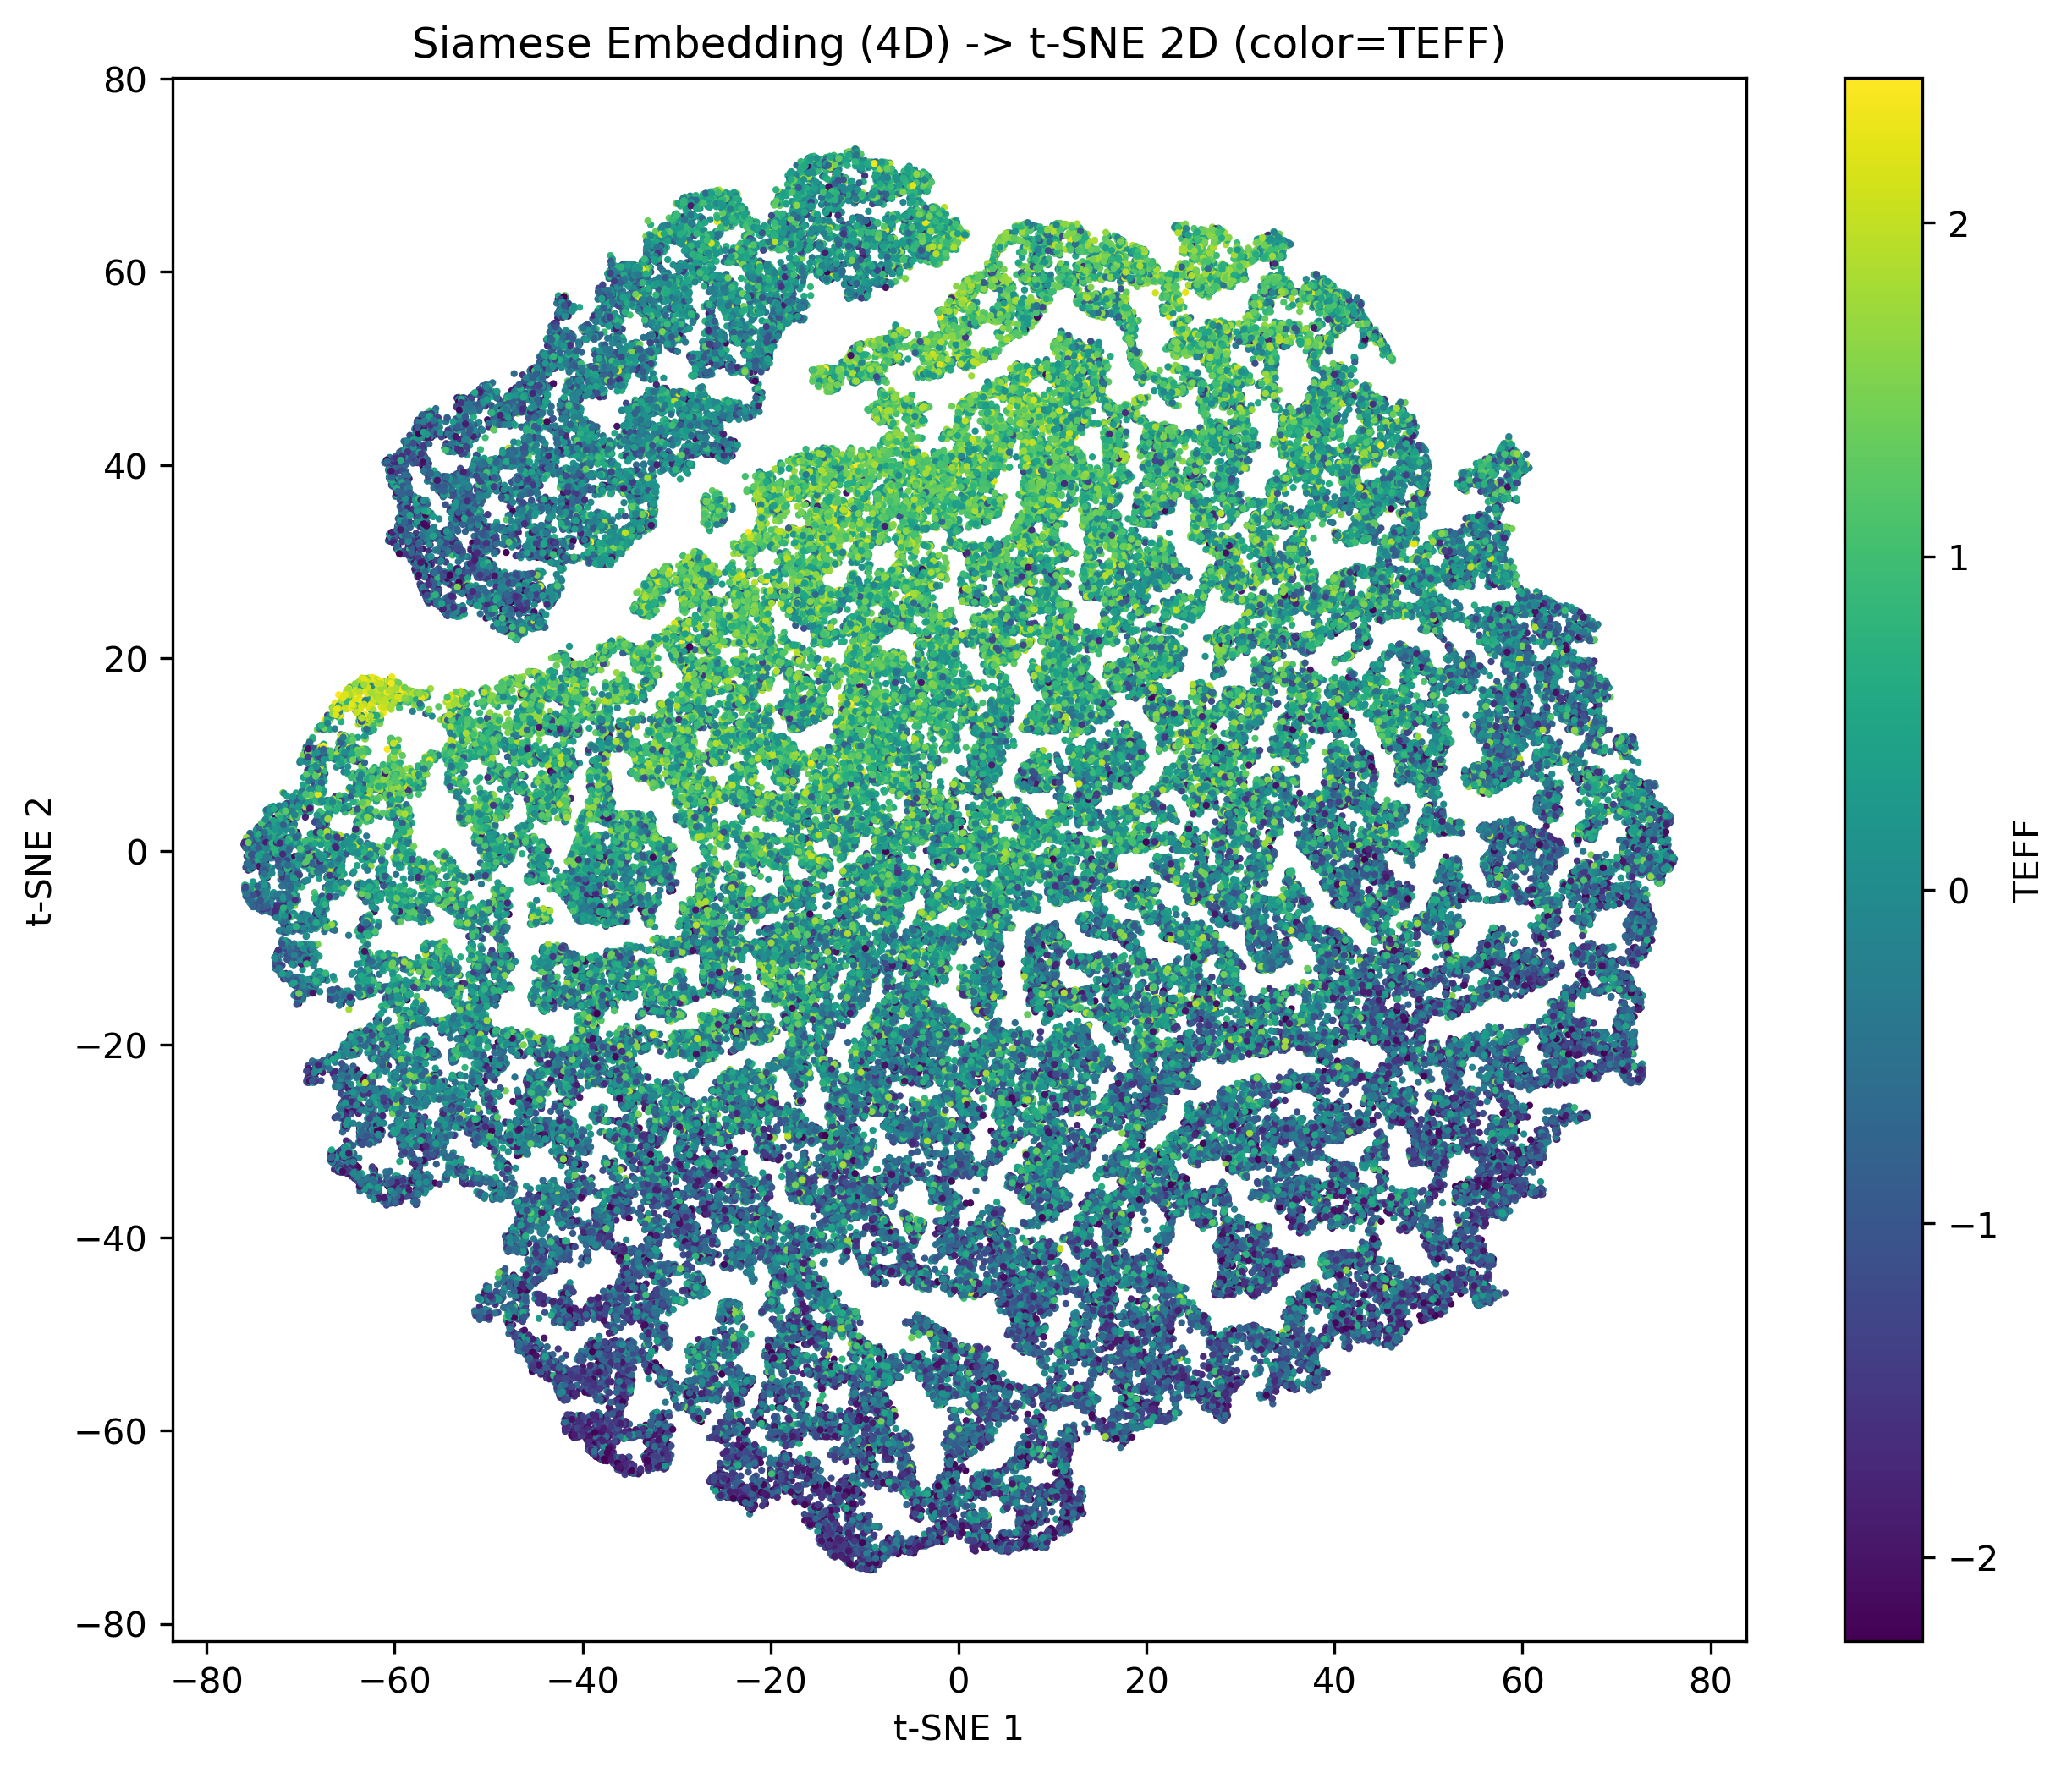

In [32]:
# Suppose we want the original TEFF from train+test concatenated

data = pd.concat([train_df, test_df], ignore_index=True)

fig, ax = plt.subplots(figsize=(10,8), dpi=300)
sc = ax.scatter(z_2d_df["dim1"], z_2d_df["dim2"],
                 s=1.0, cmap='viridis', c =data["K"].values)
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Siamese Embedding (4D) -> t-SNE 2D (color=TEFF)")
plt.show()


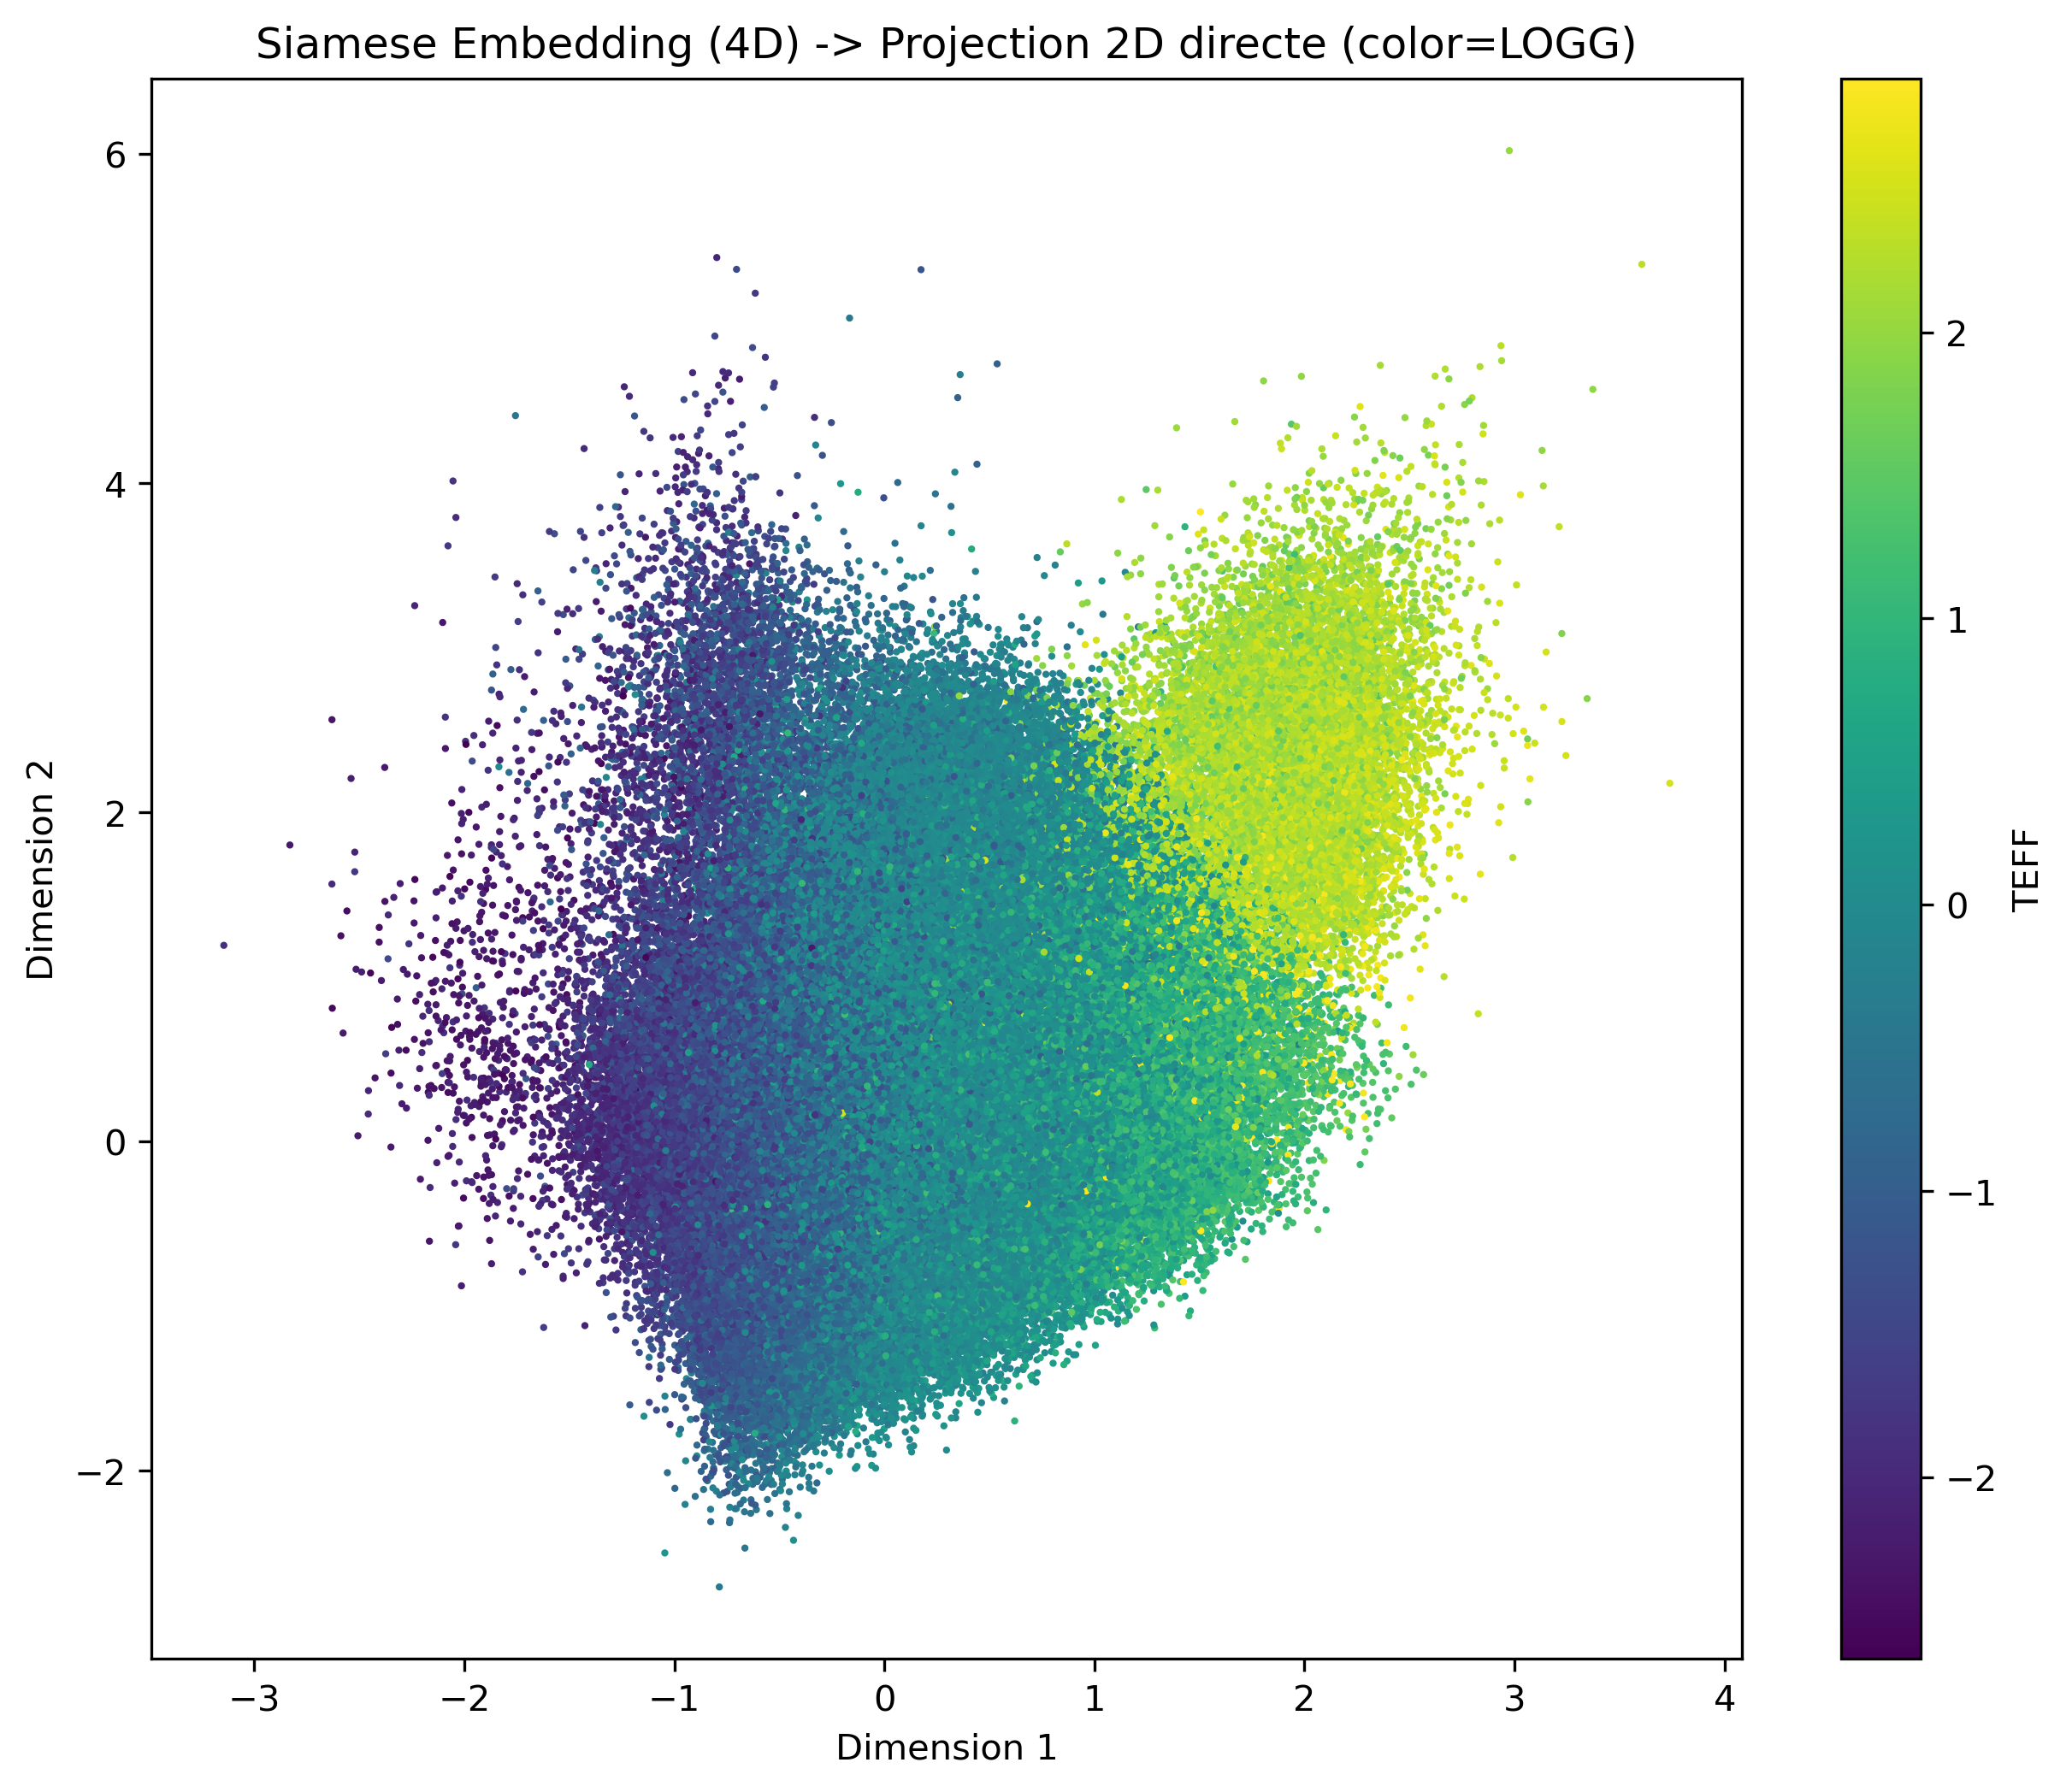

In [23]:
model.eval()
with torch.no_grad():
    # On concatène les données train et test et on les déplace sur le GPU
    X_all = torch.cat((X_train, X_test), dim=0).cuda()
    z_all, out_all = model.forward_once(X_all)  # z_all: [N, 4]

# Projection directe en 2D en sélectionnant les deux premières dimensions
z_2d_direct = z_all[:, :2].cpu().numpy()  # shape [N,2]

# Création d'un DataFrame pour faciliter le plotting (optionnel)
z_2d_df = pd.DataFrame(z_2d_direct, columns=["dim1", "dim2"])


# Plot
fig, ax = plt.subplots(figsize=(10,8), dpi=300)
sc = ax.scatter(z_2d_df["dim1"], z_2d_df["dim2"],
                c=data["LOGG"].values, s=1.0, cmap='viridis')
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Siamese Embedding (4D) -> Projection 2D directe (color=LOGG)")
plt.show()
